# Descrição do dados

- **id** - Identificador único do registro (int)

- **Time_spent_Alone** - Quantidade de tempo que a pessoa passa sozinha (float)

- **Stage_fear** - Indica se a pessoa tem medo de se apresentar em público (Yes/No - categórico binário)

- **Social_event_attendance** - Frequência de participação em eventos sociais (float)

- **Going_outside** - Frequência com que a pessoa sai de casa (float)

- **Drained_after_socializing** - Indica se a pessoa se sente cansada após socializar (Yes/No - categórico binário)

- **Friends_circle_size** - Tamanho do círculo de amigos (float)

- **Post_frequency** - Frequência de postagens (float)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.feature_selection import f_classif

from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv('train.csv')
df.head(6)

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,0,0.0,No,6.0,4.0,No,15.0,5.0,Extrovert
1,1,1.0,No,7.0,3.0,No,10.0,8.0,Extrovert
2,2,6.0,Yes,1.0,0.0,NaN,3.0,0.0,Introvert
3,3,3.0,No,7.0,3.0,No,11.0,5.0,Extrovert
4,4,1.0,No,4.0,4.0,No,13.0,NaN,Extrovert
5,5,2.0,No,8.0,5.0,No,NaN,3.0,Extrovert


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18524 entries, 0 to 18523
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         18524 non-null  int64  
 1   Time_spent_Alone           17334 non-null  float64
 2   Stage_fear                 16631 non-null  str    
 3   Social_event_attendance    17344 non-null  float64
 4   Going_outside              17058 non-null  float64
 5   Drained_after_socializing  17375 non-null  str    
 6   Friends_circle_size        17470 non-null  float64
 7   Post_frequency             17260 non-null  float64
 8   Personality                18524 non-null  str    
dtypes: float64(5), int64(1), str(3)
memory usage: 1.3 MB


In [4]:
df.describe()

,id,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,18524.000000,17334.000000,17344.000000,17058.000000,17470.000000,17260.000000
mean,9261.500000,3.137764,5.265106,4.044319,7.996737,4.982097
std,5347.562529,3.003786,2.753359,2.062580,4.223484,2.879139
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4630.750000,1.000000,3.000000,3.000000,5.000000,3.000000
50%,9261.500000,2.000000,5.000000,4.000000,8.000000,5.000000
75%,13892.250000,4.000000,8.000000,6.000000,12.000000,7.000000
max,18523.000000,11.000000,10.000000,7.000000,15.000000,10.000000


In [5]:
df.isnull().sum()

id                              0
Time_spent_Alone             1190
Stage_fear                   1893
Social_event_attendance      1180
Going_outside                1466
Drained_after_socializing    1149
Friends_circle_size          1054
Post_frequency               1264
Personality                     0
dtype: int64

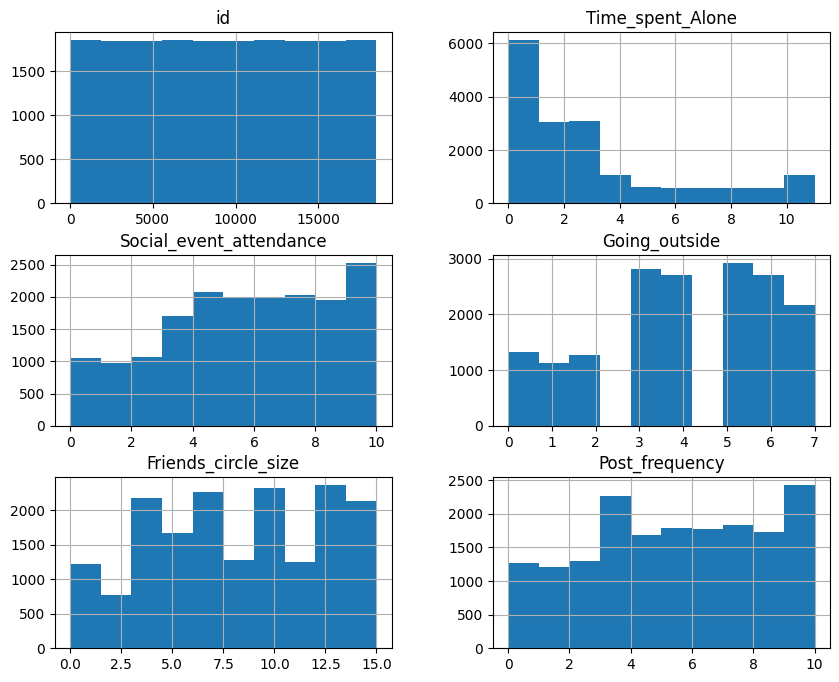

In [6]:
df.hist(figsize=(10,8))
plt.show()

In [7]:
df = df.drop_duplicates()

In [8]:
df['Going_outside'] = df['Going_outside'].fillna(df['Going_outside'].median())      

df['Social_event_attendance'] = df['Social_event_attendance'].fillna(df['Social_event_attendance'].mean())  
df['Friends_circle_size'] = df['Friends_circle_size'].fillna(df['Friends_circle_size'].mean())      
df['Post_frequency'] = df['Post_frequency'].fillna(df['Post_frequency'].mean())      

df['Time_spent_Alone'] = df['Time_spent_Alone'].fillna(df['Time_spent_Alone'].mode()[0])    
df['Stage_fear'] = df['Stage_fear'].fillna(df['Stage_fear'].mode()[0])        
df['Drained_after_socializing'] = df['Drained_after_socializing'].fillna(df['Drained_after_socializing'].mode()[0])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18524 entries, 0 to 18523
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         18524 non-null  int64  
 1   Time_spent_Alone           18524 non-null  float64
 2   Stage_fear                 18524 non-null  str    
 3   Social_event_attendance    18524 non-null  float64
 4   Going_outside              18524 non-null  float64
 5   Drained_after_socializing  18524 non-null  str    
 6   Friends_circle_size        18524 non-null  float64
 7   Post_frequency             18524 non-null  float64
 8   Personality                18524 non-null  str    
dtypes: float64(5), int64(1), str(3)
memory usage: 1.3 MB


In [9]:
df = pd.get_dummies(df, columns=['Stage_fear','Drained_after_socializing'], drop_first=True)
display(df[['Stage_fear_Yes', 'Drained_after_socializing_Yes']].head())

,Stage_fear_Yes,Drained_after_socializing_Yes
0,False,False
1,False,False
2,True,False
3,False,False
4,False,False


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18524 entries, 0 to 18523
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id                             18524 non-null  int64  
 1   Time_spent_Alone               18524 non-null  float64
 2   Social_event_attendance        18524 non-null  float64
 3   Going_outside                  18524 non-null  float64
 4   Friends_circle_size            18524 non-null  float64
 5   Post_frequency                 18524 non-null  float64
 6   Personality                    18524 non-null  str    
 7   Stage_fear_Yes                 18524 non-null  bool   
 8   Drained_after_socializing_Yes  18524 non-null  bool   
dtypes: bool(2), float64(5), int64(1), str(1)
memory usage: 1.0 MB


In [11]:
X = df.drop(columns=['Personality','Time_spent_Alone','Social_event_attendance','Going_outside',
                     'Friends_circle_size', 'Post_frequency', 'Stage_fear_Yes', 'Drained_after_socializing_Yes'])
y = df['Personality']

In [12]:
selector = SelectKBest(score_func=f_classif, k=5)
X_new = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

/home/aiko4/projetos/MachineLearn/machinelearn/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=5 is greater than n_features=1. All the features will be returned.
  warnings.warn(


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X[selected_features], y, test_size=0.2, random_state=42
)

In [14]:
smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(X_train.shape)
print(X_train_balanced.shape)

(14819, 1)
(21892, 1)
